$ \textbf{Aluna:}$ Alessandra da Silva Dias Malizia   
$ \textbf{Professor:}$ Cristiano Fernandes   
$ \textbf{Data:}$ 8 de Maio de 2026   

$ \textbf{Estudo Orientado - 2026.1}$

In [10]:
import numpy as np
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm, t, genpareto, genextreme, chi2, gamma, uniform, expon
import numdifftools as nd
from scipy.optimize import minimize
from naveau_model import NaveauModelI as naveau

In [2]:
rng = np.random.default_rng(seed=4)

In [3]:
path_results = r'C:\Users\aless\Documents\Mestrado\PUC\Tese\propostas'

# Estimação de parâmetros para dados censurados

In [3]:
def loglik_naive(params, data):
    mu, sigma = params
    if sigma <= 0:
        return np.inf
    
    return -np.sum(norm.logpdf(data, loc=mu, scale=sigma))

In [4]:
def loglik_censored(params, data, C):
    mu, sigma = params
    if sigma <= 0:
        return np.inf
    
    ll = 0
    # parte densidade
    ll += np.sum(norm.logpdf(data[data > C], loc=mu, scale=sigma))
    # parte censurada (CDF)
    ll += np.sum(norm.logcdf(C, loc=mu, scale=sigma)) * len(data[data <= C])
    return -ll

In [ ]:
size = 1_000
mu = 15
sigma = 10.7
Cs = np.arange(0.5, 20, 2.5)

n_sim = 5_000
cols = pd.MultiIndex.from_product([['mu', 'sigma'], ['Naive', 'Censored']])
df_results = pd.DataFrame(index=Cs, columns=cols)

for C in Cs:
    # simulação das amostras
    sample = rng.normal(loc=mu, scale=sigma, size=(n_sim,size))
    sample_censored = np.maximum(sample, C)
    
    # estimação dos parâmteros
    naive_estimates, cens_estimates = np.zeros((n_sim, 2)), np.zeros((n_sim, 2))
    mu0, sigma0 = np.mean(sample_censored, axis=1), np.std(sample_censored, axis=1)

    for i in tqdm(range(n_sim)):
        # fit naive
        res = minimize(loglik_naive, x0=[mu0[i], sigma0[i]], args=(sample_censored[i],))
        naive_estimates[i] = res.x
    
        # fit censored
        res = minimize(loglik_censored, x0=[mu0[i], sigma0[i]], args=(sample_censored[i], C))
        cens_estimates[i] = res.x
    
        # results
        df_results.at[C,('mu','Censored')] = np.mean(np.abs(cens_estimates[:,0]-mu))
        df_results.at[C,('sigma','Censored')] = np.mean(np.abs(cens_estimates[:,0]-sigma))
        df_results.at[C,('mu','Naive')] = np.mean(np.abs(naive_estimates[:,0]-mu))
        df_results.at[C,('sigma','Naive')] = np.mean(np.abs(naive_estimates[:,0]-sigma))

# df_results.to_csv(path_results + r'\simulacao_censored.csv')
df_results = df_results.read_csv(path_results + r'\simulacao_censored.csv', index_col=0)

In [44]:
print('MAE das estimações:')
df_results.index.name = 'C'
df_results.astype(float).round(2)

MAE das estimações:


mu           sigma         
     Naive Censored  Naive Censored
C                                  
0.5   0.45     0.27   4.73     4.29
3.0   0.71     0.27   5.01     4.30
5.5   1.10     0.27   5.40     4.30
8.0   1.65     0.28   5.95     4.30
10.5  2.39     0.29   6.69     4.30
13.0  3.34     0.31   7.64     4.30
15.5  4.53     0.34   8.83     4.30
18.0  5.94     0.38  10.24     4.29

# Simulação de EGPD   

$$
\begin{align}
F(x)
&=
G\left\{
H_\xi\left(\dfrac{x}{\sigma}\right)
\right\}, \qquad \sigma>0\\
G(v)
&=
v^\kappa,
\qquad
\kappa>0
\end{align}
$$

## Xi = 0.2

In [27]:
model = naveau(
    kappa=0.7,
    sigma=1.5,
    xi=0.2
)

sample = model.rvs(size=1_000)
x = np.linspace(0.7, 20, 500)

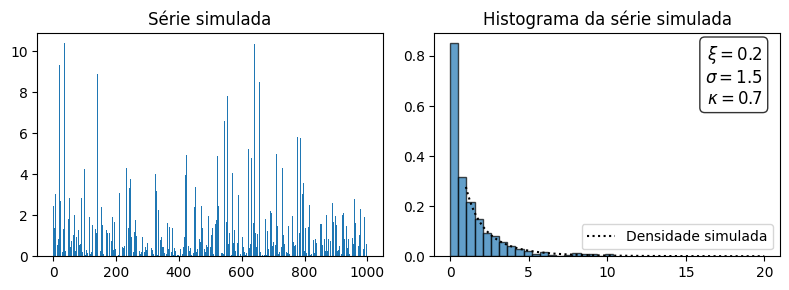

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))

ax[0].bar(np.arange(len(sample)), sample)
ax[0].set_title('Série simulada')


textstr = f'$\\xi={model.xi}$\n$\\sigma={model.sigma}$\n$\\kappa={model.kappa}$'
ax[1].hist(sample, bins=20, density=True, alpha=0.7, edgecolor='black')
ax[1].plot(x, model.pdf(x), 'k', linestyle=':', label='Densidade simulada')
ax[1].set_title('Histograma da série simulada')
ax[1].legend()
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax[1].text(0.95, 0.95, textstr, transform=ax[1].transAxes, fontsize=12,
           verticalalignment='top', horizontalalignment='right', bbox=props)

fig.tight_layout()
plt.show()

In [28]:
fitted = naveau.fit(sample)
print("Parâmetros verdadeiros: kappa={:.2f}, sigma={:.2f}, xi={:.2f}".format(model.kappa, model.sigma, model.xi))
print('\nParâmetros estimados:')
_ = fitted.summary()

Parâmetros verdadeiros: kappa=0.70, sigma=1.50, xi=0.20

Parâmetros estimados:
kappa = 0.687 (0.62, 0.75)
sigma = 1.603 (1.36, 1.85)
xi = 0.144 (0.05, 0.23)


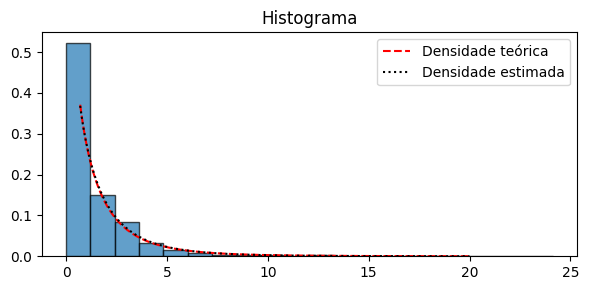

In [29]:
# plot do fit
fig, ax = plt.subplots(figsize=(6, 3))

ax.hist(sample, bins=20, density=True, alpha=0.7, edgecolor='black')
ax.plot(x, model.pdf(x), 'r', linestyle='--', label='Densidade teórica')
ax.plot(x, fitted.pdf(x), 'k', linestyle=':', label='Densidade estimada')
ax.set_title('Histograma')
ax.legend()

fig.tight_layout()
plt.show()

## Xi = 0

In [30]:
model = naveau(
    kappa=0.7,
    sigma=1.5,
    xi=0
)

sample = model.rvs(size=1_000)
x = np.linspace(0.7, 20, 500)

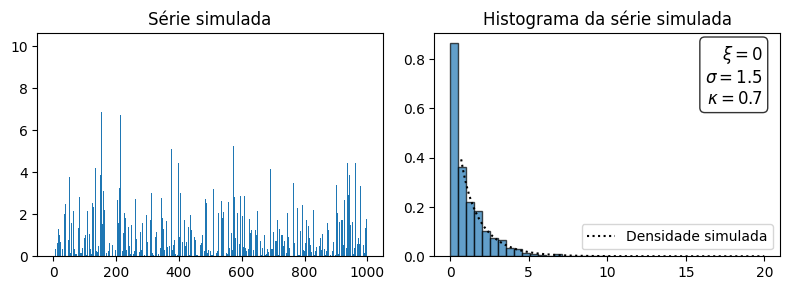

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))

ax[0].bar(np.arange(len(sample)), sample)
ax[0].set_title('Série simulada')


textstr = f'$\\xi={model.xi}$\n$\\sigma={model.sigma}$\n$\\kappa={model.kappa}$'
ax[1].hist(sample, bins=20, density=True, alpha=0.7, edgecolor='black')
ax[1].plot(x, model.pdf(x), 'k', linestyle=':', label='Densidade simulada')
ax[1].set_title('Histograma da série simulada')
ax[1].legend()
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax[1].text(0.95, 0.95, textstr, transform=ax[1].transAxes, fontsize=12,
           verticalalignment='top', horizontalalignment='right', bbox=props)

fig.tight_layout()
plt.show()

In [32]:
fitted = naveau.fit(sample)
print("Parâmetros verdadeiros: kappa={:.2f}, sigma={:.2f}, xi={:.2f}".format(model.kappa, model.sigma, model.xi))
print('\nParâmetros estimados:')
_ = fitted.summary()

Parâmetros verdadeiros: kappa=0.70, sigma=1.50, xi=0.00

Parâmetros estimados:
kappa = 0.707 (0.65, 0.77)
sigma = 1.463 (1.26, 1.66)
xi = -0.056 (-0.13, 0.02)


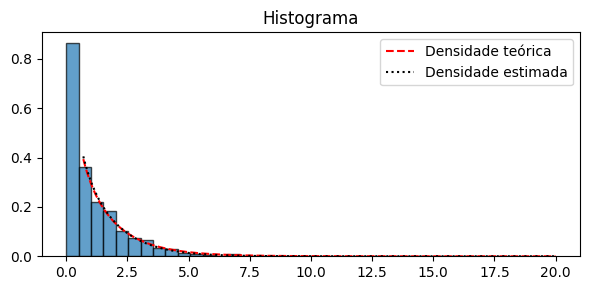

In [33]:
# plot do fit
fig, ax = plt.subplots(figsize=(6, 3))

ax.hist(sample, bins=20, density=True, alpha=0.7, edgecolor='black')
ax.plot(x, model.pdf(x), 'r', linestyle='--', label='Densidade teórica')
ax.plot(x, fitted.pdf(x), 'k', linestyle=':', label='Densidade estimada')
ax.set_title('Histograma')
ax.legend()

fig.tight_layout()
plt.show()